In [1]:
import sys
!{sys.executable} -m pip install yfinance --user


In [2]:
import yfinance as yf  
data = yf.download('AAPL', start='2020-01-01')

[*********************100%***********************]  1 of 1 completed


In [3]:
data.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400536,72.460799,71.156697,71.409800,135480400
2020-01-03,71.696625,72.455943,71.472447,71.629130,146322800
2020-01-06,72.267937,72.306506,70.568510,70.819208,118387200
2020-01-07,71.928047,72.533087,71.708687,72.277571,108872000
2020-01-08,73.085098,73.386416,71.631544,71.631544,132079200


In [4]:
data.tail()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2026-03-31,253.789993,255.479996,247.100006,247.910004,49598100
2026-04-01,255.630005,256.179993,253.330002,254.080002,40059400
2026-04-02,255.919998,256.130005,250.649994,254.199997,31289400
2026-04-06,258.859985,262.160004,256.459991,256.510010,29297900
2026-04-07,249.625000,256.190002,249.000000,256.154999,9193512


In [5]:
data.shape

(1573, 5)

In [6]:
data.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,1573.000000,1573.000000,1573.000000,1573.000000,1.573000e+03
mean,168.715017,170.453950,166.833048,168.574723,8.297592e+07
std,52.213892,52.578467,51.845255,52.210691,5.095643e+07
min,54.213608,55.211524,51.372088,55.110042,9.193512e+06
25%,133.111877,134.486568,131.258346,132.854228,4.959810e+07
50%,166.484833,168.012559,165.047922,166.821764,6.890300e+07
75%,208.146591,210.788539,205.520495,207.857469,9.832200e+07
max,285.922455,288.350192,283.035157,285.932471,4.265100e+08


In [7]:
# Data cleaning & preprocessing

In [8]:
data.dtypes

Price   Ticker
Close   AAPL      float64
High    AAPL      float64
Low     AAPL      float64
Open    AAPL      float64
Volume  AAPL        int64
dtype: object

In [9]:
data.isnull().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

In [10]:
data.duplicated().sum()

np.int64(0)

In [11]:
#Feature engineering

In [4]:
data['sma_20']=data['Close'].rolling(window=20).mean()
data['sma_50']=data['Close'].rolling(window=50).mean()


In [5]:
data['ema_20']=data['Close'].ewm(span=20,adjust=False).mean()
data['ema_50']=data['Close'].ewm(span=50,adjust=False).mean()


In [6]:
data['daily_return']=data['Close'].pct_change()*100

In [7]:
data.head()

Price,Close,High,Low,Open,Volume,sma_20,sma_50,ema_20,ema_50,daily_return
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,
Date,,,,,,,,,,
2020-01-02,72.400513,72.460776,71.156674,71.409778,135480400,NaN,NaN,72.400513,72.400513,NaN
2020-01-03,71.696632,72.455950,71.472454,71.629138,146322800,NaN,NaN,72.333476,72.372910,-0.972203
2020-01-06,72.267952,72.306521,70.568525,70.819223,118387200,NaN,NaN,72.327236,72.368794,0.796857
2020-01-07,71.928062,72.533103,71.708703,72.277586,108872000,NaN,NaN,72.289220,72.351510,-0.470318
2020-01-08,73.085121,73.386438,71.631567,71.631567,132079200,NaN,NaN,72.365020,72.380279,1.608633


In [16]:
# EDA

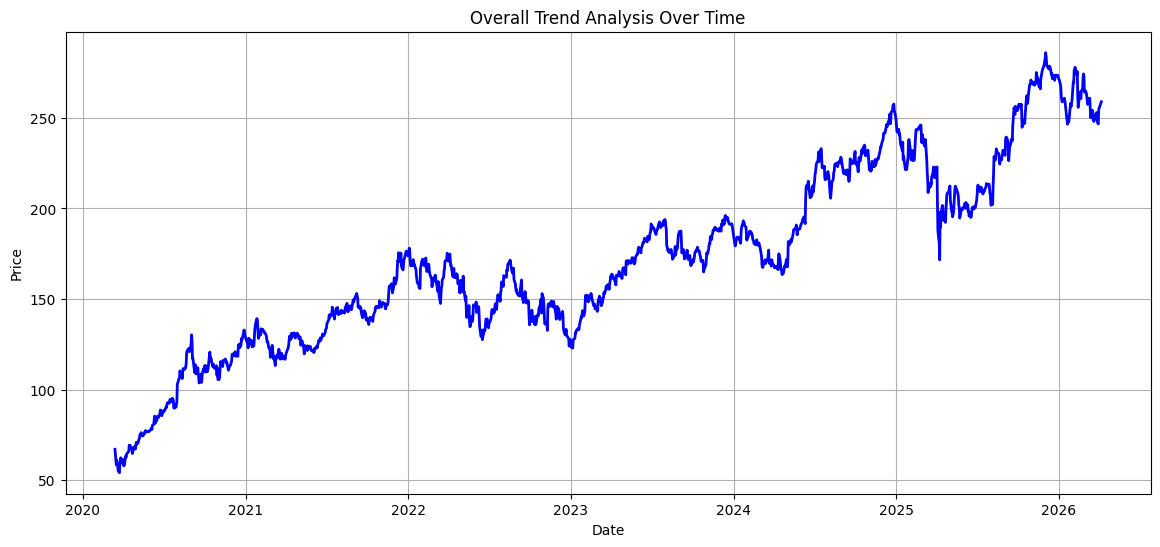

In [75]:
# Overall Trend Analysis

plt.figure(figsize=(14,6))
plt.plot(data['Close'],label='Price',color='blue',linewidth=2)
plt.title('Overall Trend Analysis Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.show()

In [77]:
'''
#Insights

- The stock shows an overall upward trend overtime.

- Also shows a remarkable growth overtime from price of nearly 70 to 280 from Year 2020 to 2026

- It can also be observed that whenever the stock price went down, it recovered higher than before
which shows the stock's attribute of being a long term and fundamentally strong stock
'''

"\n#Insights\n\n- The stock shows an overall upward trend overtime.\n\n- Also shows a remarkable growth overtime from price of nearly 70 to 280 from Year 2020 to 2026\n\n- It can also be observed that whenever the stock price went down, it recovered higher than before\nwhich shows the stock's attribute of being a long term and fundamentally strong stock\n"

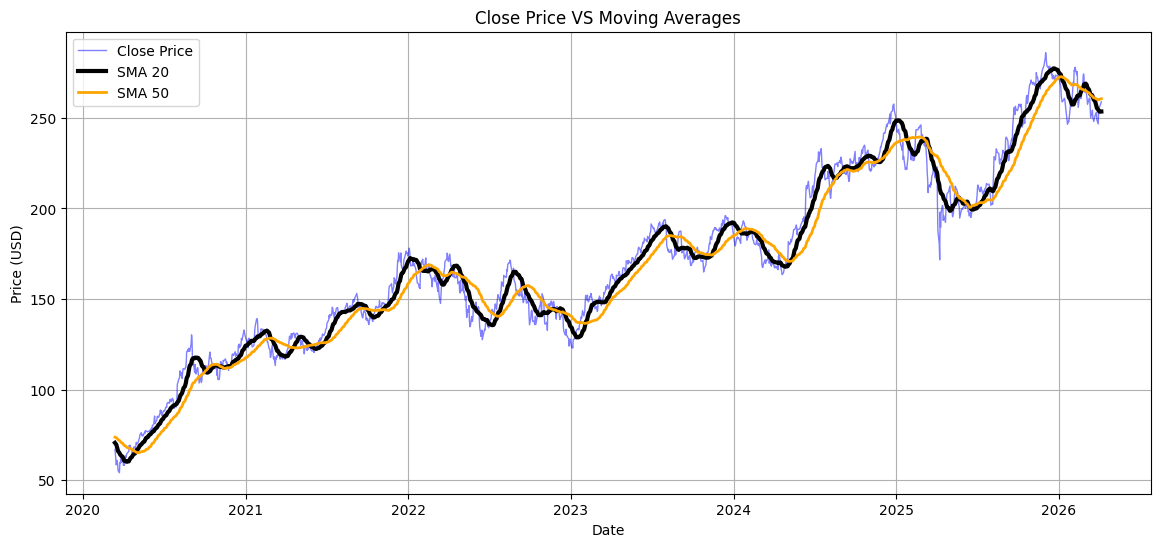

In [82]:
# Closing price v/s moving average

import matplotlib.pyplot as plt
plt.figure(figsize=(14,6))
plt.plot(data['Close'],label='Close Price',color='blue',alpha=0.5,linewidth=1)
plt.plot(data['sma_20'],label='SMA 20',color='black',linewidth=3)
plt.plot(data['sma_50'],label='SMA 50',color='orange',linewidth=2)
plt.title('Close Price VS Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

In [18]:
'''
Insights:

- Price is consistently staying above MA that is indicating a bullish trend

- Also simple moving average of 20 days and simple moving average of 50 days are moving very close
to each other throughout the period which is showing a stable and consistent trend without any 
major crossover signals
'''

'\nInsights:\n\n- Price is consistently staying above MA that is indicating a bullish trend\n\n- Also simple moving average of 20 days and simple moving average of 50 days are moving very close\nto each other throughout the period which is showing a stable and consistent trend without any \nmajor crossover signals\n'

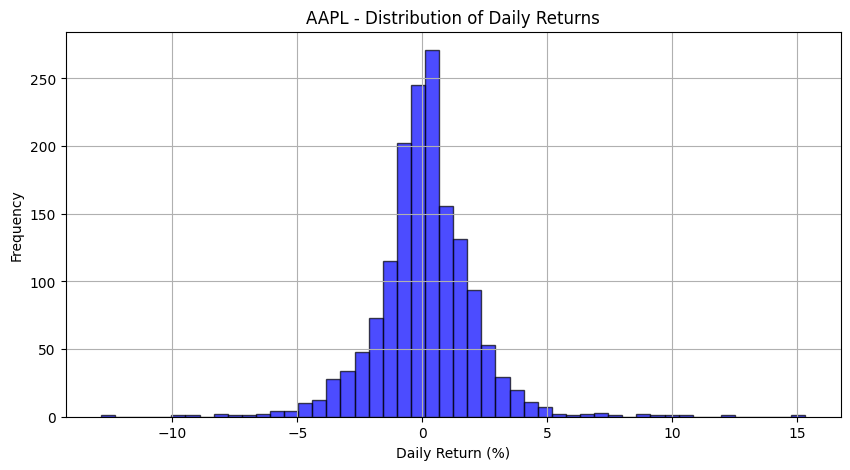

In [19]:
#Volatility Analysis
plt.figure(figsize=(10, 5))
plt.hist(data['daily_return'].dropna(), bins=50, color='blue', edgecolor='black', alpha=0.7)
plt.title('AAPL - Distribution of Daily Returns')
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [20]:
'''
Insights:

-Daily returns are concentrated between -5% to 5% states that on a typical day AAPL rarely moves
more than 5% in either direction

- Rare extreme events beyond ±10% exist but are very infrequent, suggesting they were driven by 
specific news events rather than regular market behavior.

- Also centered slightly above 0%, confirming a positive bias with low volatility

'''

'\nInsights:\n\n-Daily returns are concentrated between -5% to 5% states that on a typical day AAPL rarely moves\nmore than 5% in either direction\n\n- Rare extreme events beyond ±10% exist but are very infrequent, suggesting they were driven by \nspecific news events rather than regular market behavior.\n\n- Also centered slightly above 0%, confirming a positive bias with low volatility\n\n'

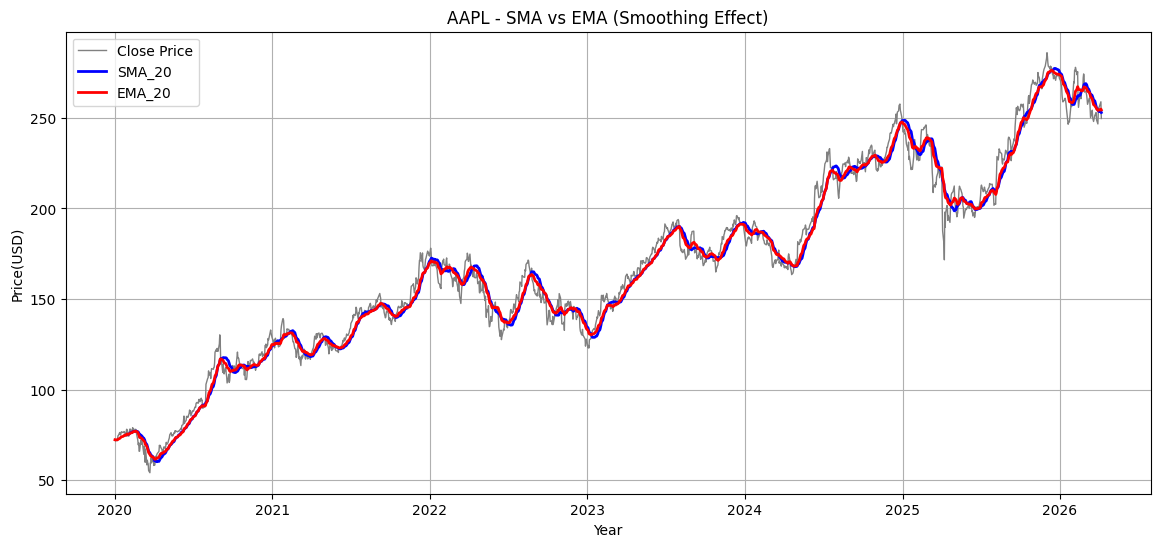

In [22]:
#EMA V/S MA

plt.figure(figsize=(14,6))
plt.plot(data['Close'], label='Close Price', color='grey',linewidth=1)
plt.plot(data['sma_20'],label='SMA_20',color='blue',linewidth=2)
plt.plot(data['ema_20'],label='EMA_20',color='red',linewidth=2)
plt.title('AAPL - SMA vs EMA (Smoothing Effect)')
plt.xlabel('Year')
plt.ylabel('Price(USD)')
plt.legend()
plt.grid(True)
plt.show()


In [23]:
'''
Insights:

-AAPL shows a strong long term uptrend from ~$75 in 2020 to ~$250 in 2026, with EMA_20 consistently
hugging the Close price more tightly than SMA_20, confirming EMA's faster reaction to price 
movements during both rallies and dips
'''

"\nInsights:\n\n-AAPL shows a strong long term uptrend from ~$75 in 2020 to ~$250 in 2026, with EMA_20 consistently\nhugging the Close price more tightly than SMA_20, confirming EMA's faster reaction to price \nmovements during both rallies and dips\n"

In [24]:
#Prediction Model

In [25]:
data.head()

Price,Close,High,Low,Open,Volume,sma_20,sma_50,ema_20,ema_50,daily_return
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,
Date,,,,,,,,,,
2020-01-02,72.400536,72.460799,71.156697,71.409800,135480400,NaN,NaN,72.400536,72.400536,NaN
2020-01-03,71.696625,72.455943,71.472447,71.629130,146322800,NaN,NaN,72.333496,72.372931,-0.972245
2020-01-06,72.267937,72.306506,70.568510,70.819208,118387200,NaN,NaN,72.327253,72.368814,0.796846
2020-01-07,71.928047,72.533087,71.708687,72.277571,108872000,NaN,NaN,72.289233,72.351529,-0.470319
2020-01-08,73.085098,73.386416,71.631544,71.631544,132079200,NaN,NaN,72.365030,72.380296,1.608623


In [8]:
data['Target']=data['Close'].shift(-1)
data.dropna(inplace=True)

In [9]:
x=data[['sma_20','sma_50','ema_20','ema_50','daily_return','Volume']]
y=data['Target']

In [18]:
split_idx = int(0.8 * len(data))
x_train = x.iloc[:split_idx].copy()
x_test = x.iloc[split_idx:].copy()
y_train = y.iloc[:split_idx].copy()
y_test = y.iloc[split_idx:].copy()

In [23]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
y_pred=model.predict(x_test)

In [22]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import numpy as np
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'MAE  : {mae:.2f}')
print(f'RMSE : {rmse:.2f}')
print(f'R2   : {r2:.2f}')

MAE  : 4.78
RMSE : 6.48
R2   : 0.94


In [25]:
avg_price = y_test.mean()
mae_pct = (mae / avg_price) * 100
print(f'MAE as % of avg price: {mae_pct:.2f}%')

MAE as % of avg price: 2.01%


In [84]:
data['Predicted_Price']=model.predict(x) #for using in power bi

In [70]:
data.to_csv('aapl_analysis.csv',index=True)